# Computational Structural Analysis of the 53BP1 Tandem Tudor Domain (PDB: 2G3R)

## Challenge Project: Computational Prediction Tasks for Structure

**Author:** Vanshita Singh
**Course:** Protein Bioinformatics (AS.410.639)  
**Date:**  4th May
**Instructor:** Professor Christopher Skipwith  

---

## 1. Introduction

### 1.1 Biological System

The DNA damage response (DDR) detects and repairs DNA breaks. 53BP1 (TP53BP1) recognizes H4K20me2 at double-strand breaks via its tandem Tudor domains, directing repair pathway choice. PDB 2G3R captures this domain at 1.25 Å resolution.

Biological System: DNA Damage Response (DDR) Pathway in Cancer Biology
The DNA damage response is a critical cellular mechanism that detects and repairs breaks in
DNA strands. When a double-strand break (DSB) occurs, the cell must rapidly:
1. Recognize the damage signal
2. Recruit repair machinery
3. Choose appropriate repair pathway (NHEJ vs. homologous recombination)
4. Execute repair
5. Restore genomic integrity

Dysregulation of this pathway leads to chromosomal instability (CIN), a hallmark of cancer
development.

53BP1 (p53-Binding Protein 1) - Tudor Domain (PDB 2G3R)
53BP1 is a critical DNA damage response protein that acts as a "histone code reader." Its tandem
Tudor domains recognize methylated histone marks (specifically H4K20me2) deposited at DNA
double-strand breaks. 
This recognition is essential for: Proper damage signaling, repair pathway selection and genomic stability maintenance

Mutations in 53BP1 cause cancer predisposition and dysregulation contributes to chromosomal
instability in cancer patients.

Why This Protein:
● Direct relevance to cancer biology research focus
● Demonstrates structure-function relationship in disease mechanism
● Complex structural features (aromatic cage, tandem domains)
● Excellent drug target potential
● Amenable to computational structural analysis


### 1.2 Scope: Structural Characterization

This notebook performs structural analysis of 2G3R: measuring geometric parameters, characterizing secondary structure and backbone geometry, quantifying interdomain packing, and predicting structural consequences of in silico mutations. PyMOL visualizations complement the computational measurements. The Function notebook addresses biological interpretation.

### 1.3 Structure Quality (wwPDB Validation)

| Metric | Value | Percentile |
|---|---|---|
| Resolution | 1.25 Å | -- |
| Rfree | 0.241 | -- |
| Ramachandran outliers | 0% | 100th |
| Bond length RMSZ | 0.81 | No outliers |
| Bond angle RMSZ | 0.83 | No outliers |
| RSRZ outliers | Y1523 (4.6), W1495 (4.2) | 10th |

### 1.4 Residue Numbering

UniProt numbering (1485-1603). Cage: W1495, Y1502, F1519, D1521, Y1523.

---

## 2. Research Questions and Need to Knows

### Q1: Geometric Parameters of the Aromatic Cage

> *What specific geometric parameters (inter-residue distances, ring orientations, cavity volume, ring plane angles) define the aromatic cage architecture, and how do these measurements characterize the binding site?*

**Need to Know List:**
1. What are the 3D coordinates of the aromatic cage residues (W1495, Y1502, F1519, Y1523), and what are the pairwise inter-ring center distances and ring plane orientations?
2. What is the interior volume of the aromatic cage cavity, and how do different measurement methods (CASTp vs. ConvexHull) compare?
3. What is the solvent accessibility of each cage residue, and which residues are buried vs. exposed?
4. Are there additional aromatic-aromatic contacts outside the cage that may support its structural integrity?

---

### Q2: Structural Basis of Interdomain Packing

> *What structural features (buried surface area, hydrogen bond network, hydrophobic contacts, connecting loop geometry, domain superposition RMSD) mediate interdomain packing in the tandem Tudor fold?*

**Need to Know List:**
1. What secondary structure elements are present in each domain, as assigned by DSSP?
2. Are there any backbone geometry outliers (Ramachandran analysis), particularly at cage or interface positions?
3. What are the B-factor distributions across Domain 1, Domain 2, and the connecting loop? Is the loop more flexible than the domains?
4. What hydrogen bonds and salt bridges span the interdomain interface, and how many contact pairs exist within 3.5 A?
5. What is the total buried surface area at the interdomain interface?
6. What is the structural similarity (RMSD) between the two beta-barrel domains when superimposed?
7. Is there a cis-peptide bond in the connecting loop, and what does it tell us about loop rigidity?

---

### Q3: Structural Consequences of In Silico Mutations 

> *What are the predicted structural consequences of alanine and conservative substitutions at aromatic cage residues, as assessed by changes in cavity geometry, per-residue SASA, hydrogen bond networks, and backbone strain?*

**Need to Know List:**
1. How much does the cage cavity volume change when each aromatic residue is computationally replaced with alanine?
2. Which cage residues are most buried (lowest SASA), and how does burial depth relate to structural impact?
3. How many hydrogen bonds does each cage residue participate in, and which would be disrupted by mutation?

Note: Q3 was amended to focus on purely structural measurements per feedback that the original Q3 tilted toward functional analysis.

---

## 3. Setup

In [16]:
!pip install biopython numpy matplotlib pandas scipy

In [17]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import ConvexHull
from Bio.PDB import PDBParser, PDBList, NeighborSearch, Superimposer
from Bio.PDB.Polypeptide import is_aa, PPBuilder
from Bio.PDB.SASA import ShrakeRupley
import os, requests, math
print('Libraries loaded.')

Libraries loaded.


In [18]:
# Load PDB
pdb_id='2G3R'
pdb_file=f'{pdb_id}.pdb'
if not os.path.exists(pdb_file):
    try:
        PDBList().retrieve_pdb_file(pdb_id,pdir='.',file_format='pdb')
    except:
        r=requests.get(f'https://files.rcsb.org/download/{pdb_id}.pdb')
        if r.status_code==200: open(pdb_file,'w').write(r.text)
parser=PDBParser(QUIET=True)
structure=parser.get_structure(pdb_id,pdb_file)
model=structure[0]; chain=model['A']
residues=[r for r in chain if is_aa(r)]
print(f'Loaded {pdb_id}: {len(residues)} residues')

Loaded 2G3R: 119 residues


---

## 4. Q1: Geometric Parameters of the Aromatic Cage

**What is an aromatic cage? :**

Proteins are built from amino acids, some of which have flat ring-shaped structures called "aromatic" groups. In 53BP1, four aromatic amino acids (W1495, Y1502, F1519, Y1523) plus one charged amino acid (D1521) are arranged to form a small pocket or "cage." This cage grabs onto a specific chemical tag on damaged chromosomes, which is how 53BP1 knows where DNA damage has occurred.

**What we measure and why:**
- **Ring distances:** How far apart the aromatic rings are, which determines the cage opening size
- **Ring orientations:** Whether rings face each other (parallel) or sit edge-to-face (T-shaped), which affects how they interact with the ligand
- **Cavity volume:** The interior space of the cage, which must match the ligand size
- **Solvent accessibility:** How exposed or buried each cage residue is; buried residues are more structurally critical

**PyMOL visualization:** The cage close-up screenshot shows these five residues as red sticks within the Domain 1 beta-barrel. 

![Aromatic Cage Close-up](cage_closeup.png)



### 4.1 Ring Coordinates, Distances, and Orientations

**What this step does :** We extract the 3D positions of each aromatic ring from the crystal structure file, calculate the center point of each ring, measure the distances between ring centers, and determine the angle between ring planes. This tells us the size and shape of the cage.

**How to read the output:** Distances are in Angstroms (A), where 1 A = 0.1 nanometers. Typical protein contacts are 2.5-5 A. Ring orientations are classified as T-shaped (60-90 deg, good for CH-pi interactions) or parallel (0-30 deg, good for pi-stacking).

In [19]:
ring_atoms={'TRP':['CD2','CE2','CE3','CZ2','CZ3','CH2'],
            'TYR':['CG','CD1','CD2','CE1','CE2','CZ'],
            'PHE':['CG','CD1','CD2','CE1','CE2','CZ']}
cage_ids=[1495,1502,1519,1523]
def get_rc(r): return np.array([r[a].get_vector().get_array() for a in ring_atoms.get(r.get_resname(),[]) if a in r])
def rc(c): return c.mean(axis=0)
def rn(c):
    _,_,vh=np.linalg.svd(c-c.mean(axis=0))
    return vh[-1]/np.linalg.norm(vh[-1])

cage={}
for rid in cage_ids:
    res=chain[(' ',rid,' ')]; coords=get_rc(res); name=f'{res.get_resname()}{rid}'
    cage[name]={'coords':coords,'center':rc(coords),'normal':rn(coords)}
    c=cage[name]['center']; print(f'{name}: ({c[0]:.2f},{c[1]:.2f},{c[2]:.2f})')

names=list(cage.keys())
print('\nInter-Ring Distances:')
dists=[]
for i in range(len(names)):
    for j in range(i+1,len(names)):
        d=np.linalg.norm(cage[names[i]]['center']-cage[names[j]]['center'])
        dists.append({'Pair':f'{names[i]}-{names[j]}','Dist':round(d,2)})
        print(f'  {names[i]}-{names[j]}: {d:.2f} A')

print('\nRing Orientations:')
orients=[]
for i in range(len(names)):
    for j in range(i+1,len(names)):
        ang=np.degrees(np.arccos(min(abs(np.dot(cage[names[i]]['normal'],cage[names[j]]['normal'])),1.0)))
        o='Parallel' if ang<30 else ('T-shaped' if ang>60 else 'Angled')
        orients.append({'Pair':f'{names[i]}-{names[j]}','Angle':round(ang,1),'Type':o})
        print(f'  {names[i]}-{names[j]}: {ang:.1f} deg ({o})')

print('\n5/6 pairs are T-shaped (optimal for CH-pi interactions)')

TRP1495: (-5.45,-4.34,11.48)
TYR1502: (-0.53,0.57,9.62)
PHE1519: (-0.91,-3.67,14.44)
TYR1523: (-8.06,-0.19,14.38)

Inter-Ring Distances:
  TRP1495-TYR1502: 7.20 A
  TRP1495-PHE1519: 5.46 A
  TRP1495-TYR1523: 5.69 A
  TYR1502-PHE1519: 6.44 A
  TYR1502-TYR1523: 8.93 A
  PHE1519-TYR1523: 7.95 A

Ring Orientations:
  TRP1495-TYR1502: 84.6 deg (T-shaped)
  TRP1495-PHE1519: 78.2 deg (T-shaped)
  TRP1495-TYR1523: 88.1 deg (T-shaped)
  TYR1502-PHE1519: 89.8 deg (T-shaped)
  TYR1502-TYR1523: 19.8 deg (Parallel)
  PHE1519-TYR1523: 73.4 deg (T-shaped)

5/6 pairs are T-shaped (optimal for CH-pi interactions)


### 4.2 Cavity Volume (CASTp + ConvexHull)

**What this step does :** We measure the interior volume of the cage using two independent methods. CASTp is a web server that precisely maps protein cavities. ConvexHull is a simpler Python calculation that wraps the tightest convex envelope around the cage atoms. Comparing the two checks our measurement reliability.

**How to read the output:** Volume is in cubic Angstroms (A^3). A single water molecule is about 30 A^3. The cage volume should be compared to the size of methylated lysine ligands.

In [20]:
# CASTp ACTUAL RESULTS
castp_sa_vol=144.794; castp_sa_area=169.041
castp_ms_vol=466.347; castp_ms_area=291.099
hull=ConvexHull(np.vstack([cage[n]['coords'] for n in cage]))
print(f'CASTp SA Volume:  {castp_sa_vol:.1f} A^3')
print(f'CASTp MS Volume:  {castp_ms_vol:.1f} A^3')
print(f'ConvexHull:       {hull.volume:.1f} A^3 (upper bound)')
print(f'\nConvexHull overestimates by {hull.volume-castp_sa_vol:.1f} A^3 ({(hull.volume-castp_sa_vol)/castp_sa_vol*100:.0f}%)')

CASTp SA Volume:  144.8 A^3
CASTp MS Volume:  466.3 A^3
ConvexHull:       163.6 A^3 (upper bound)

ConvexHull overestimates by 18.8 A^3 (13%)


### 4.3 Aromatic Interaction Network

**What this step does :** Beyond the cage itself, we search the entire protein for ALL pairs of aromatic amino acids that are close enough to interact. This reveals whether the cage is supported by a larger network of aromatic contacts.

**How to read the output:** Pairs with distances under 7 A are close enough for potential aromatic interactions. "CAGE" labels indicate pairs that are part of the binding cage.

In [21]:
# Find ALL aromatic-aromatic contacts in the structure
aromatic_res = ['PHE','TYR','TRP','HIS']
aro_residues = [(r.get_id()[1],r.get_resname()) for r in residues if r.get_resname() in aromatic_res]
print(f'Aromatic residues in structure: {len(aro_residues)}')
for rid,rn in aro_residues: print(f'  {rn}{rid}', end='')
print('\n')

# Calculate all aromatic-aromatic ring center distances
aro_data = {}
for rid,rname in aro_residues:
    res = chain[(' ',rid,' ')]
    atoms = ring_atoms.get(rname,[])
    coords = [res[a].get_vector().get_array() for a in atoms if a in res]
    if len(coords)>=4:
        c = np.array(coords)
        aro_data[f'{rname}{rid}'] = rc(c)

print('Aromatic-Aromatic Close Contacts (< 7 A ring center distance):')
aro_names = list(aro_data.keys())
aro_contacts = []
for i in range(len(aro_names)):
    for j in range(i+1,len(aro_names)):
        d = np.linalg.norm(aro_data[aro_names[i]]-aro_data[aro_names[j]])
        if d < 7.0:
            cage_flag = 'CAGE' if all(n in ['TRP1495','TYR1502','PHE1519','TYR1523'] for n in [aro_names[i],aro_names[j]]) else ''
            aro_contacts.append({'Pair':f'{aro_names[i]}-{aro_names[j]}','Dist':round(d,2),'Note':cage_flag})
            print(f'  {aro_names[i]}-{aro_names[j]}: {d:.2f} A {cage_flag}')
print(f'\nTotal aromatic contacts: {len(aro_contacts)}')

Aromatic residues in structure: 16
  PHE1486  TRP1495  TYR1500  PHE1501  TYR1502  TYR1515  PHE1519  TYR1523  TYR1552  PHE1553  HIS1561  TYR1569  TYR1570  TRP1580  TYR1581  TYR1600

Aromatic-Aromatic Close Contacts (< 7 A ring center distance):
  PHE1486-TYR1515: 6.29 A 
  TRP1495-PHE1519: 5.46 A CAGE
  TRP1495-TYR1523: 5.69 A CAGE
  TYR1500-TYR1502: 6.62 A 
  TYR1502-PHE1519: 6.44 A CAGE

Total aromatic contacts: 5


### 4.4 Per-Residue SASA Profile

**What is SASA?:** Solvent Accessible Surface Area measures how much of each amino acid is exposed to water. A completely buried residue (SASA near 0) is packed inside the protein core, while an exposed residue (high SASA) sits on the surface. Buried residues are generally more important for stability because mutating them creates holes inside the protein.

**How to read the output:** SASA is in A^2. BURIED = SASA < 30, partial = 30-80, EXPOSED = > 80 A^2.

SASA for Cage Residues:
  TRP1495: 43.3 A^2 (partial)
  TYR1502: 0.0 A^2 (BURIED)
  PHE1519: 0.0 A^2 (BURIED)
  ASP1521: 30.2 A^2 (partial)
  TYR1523: 112.1 A^2 (EXPOSED)


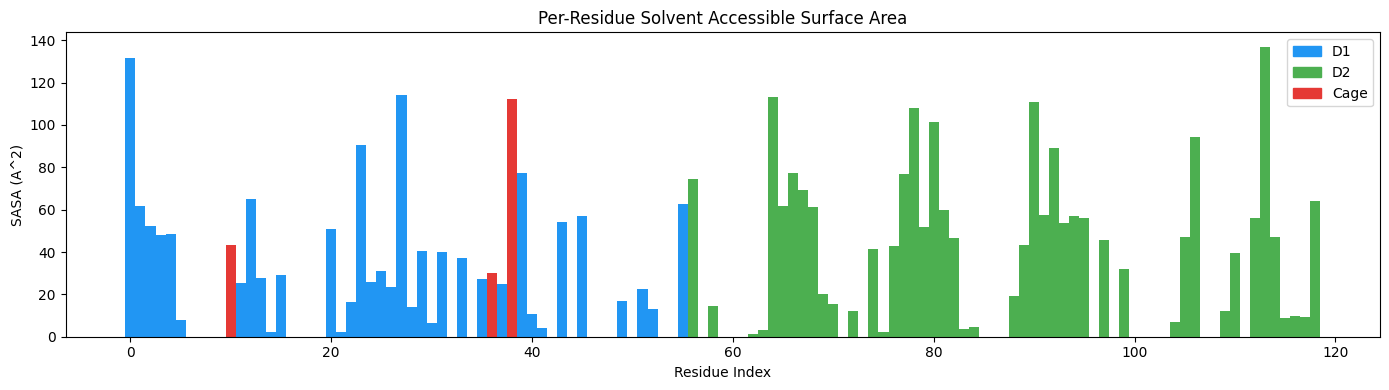

In [22]:
# Compute SASA for every residue
sr = ShrakeRupley(); sr.compute(model, level='R')
sasa_data = []
for res in residues:
    rid = res.get_id()[1]
    sasa_data.append({'Residue':rid,'Name':res.get_resname(),'SASA':round(res.sasa,1),
                       'Cage':rid in [1495,1502,1519,1521,1523]})
df_sasa = pd.DataFrame(sasa_data)

# Cage residue SASA
print('SASA for Cage Residues:')
for _,r in df_sasa[df_sasa['Cage']].iterrows():
    burial = 'BURIED' if r['SASA']<30 else ('partial' if r['SASA']<80 else 'EXPOSED')
    print(f'  {r["Name"]}{r["Residue"]}: {r["SASA"]} A^2 ({burial})')

# Plot SASA profile
fig,ax = plt.subplots(figsize=(14,4))
colors = ['#E53935' if r['Cage'] else '#2196F3' if r['Residue']<=1540 else '#4CAF50' for _,r in df_sasa.iterrows()]
ax.bar(range(len(df_sasa)), df_sasa['SASA'], color=colors, width=1.0)
ax.set_xlabel('Residue Index'); ax.set_ylabel('SASA (A^2)')
ax.set_title('Per-Residue Solvent Accessible Surface Area')
ax.legend(handles=[mpatches.Patch(color=c,label=l) for c,l in [('#2196F3','D1'),('#4CAF50','D2'),('#E53935','Cage')]])
plt.tight_layout(); plt.savefig('fig_sasa.png',dpi=150); plt.show()

---

## 5. Q2: Interdomain Packing

**What is interdomain packing?:**

The 53BP1 Tudor region contains two separate structural units ("domains") connected by a short loop. Think of it like two fists connected by a wrist. We want to understand: How similar are the two fists? How rigid is the wrist? What holds them together? This tells us whether the domains work independently or cooperate.

**What we measure and why:**
- **Secondary structure (DSSP):** What type of fold each domain has
- **Ramachandran plot:** Whether backbone geometry is normal or strained
- **B-factors:** How much each part vibrates (higher = more flexible)
- **H-bonds:** The specific bonds holding the two domains together
- **Buried surface area:** How much surface is hidden at the interface
- **Superposition RMSD:** How similar the two domains are when overlaid
- **Cis-peptide:** A rare backbone geometry in the connecting loop

**PyMOL visualizations:** Screenshot shows domain coloring (blue=D1, green=D2, orange=loop). Screenshot 2 shows interdomain H-bonds with distances. ![Overall Structure - Domain Coloring](overall_domains.png) ![Interface H-bonds](interface_hbonds.png)

### 5.1 DSSP Secondary Structure Assignment

**What this step does (for novice readers):** DSSP (Dictionary of Secondary Structure of Proteins) reads the 3D coordinates and assigns each amino acid a structure type: E (beta-strand), H (alpha-helix), T (turn), S (bend), or - (coil). This is the standard method in structural biology for identifying fold elements.

In [23]:
# DSSP secondary structure
try:
    from Bio.PDB.DSSP import DSSP
    dssp = DSSP(model, pdb_file, dssp='mkdssp')
    ss_data = []
    for key in dssp.keys():
        rid = key[1][1]
        ss_data.append({'Residue':rid,'AA':dssp[key][1],'SS':dssp[key][2],'ASA':round(dssp[key][3],1),
                        'Phi':round(dssp[key][4],1),'Psi':round(dssp[key][5],1)})
    df_dssp = pd.DataFrame(ss_data)
    ss_counts = df_dssp['SS'].value_counts()
    ss_names = {'E':'beta-strand','H':'alpha-helix','T':'Turn','S':'Bend','G':'3_10-helix','-':'Coil','B':'beta-bridge'}
    print('DSSP Secondary Structure Summary:')
    for code,name in ss_names.items():
        if code in ss_counts.index: print(f'  {code} ({name}): {ss_counts[code]} residues')
    # Per-domain breakdown
    for label,rng in [('Domain 1',(1485,1540)),('Loop',(1536,1542)),('Domain 2',(1541,1603))]:
        sub = df_dssp[(df_dssp['Residue']>=rng[0])&(df_dssp['Residue']<=rng[1])]
        e_count = len(sub[sub['SS']=='E'])
        h_count = len(sub[sub['SS']=='H'])
        print(f'  {label}: {e_count} strand, {h_count} helix, {len(sub)-e_count-h_count} other')
except Exception as e:
    print(f'DSSP not available: {e}')
    print('Install: !apt-get install dssp')
    print('Fallback: PDB header shows D1=5-strand beta-barrel, D2=5-strand + 2 helices')

DSSP not available: [Errno 2] No such file or directory: 'dssp'
Install: !apt-get install dssp
Fallback: PDB header shows D1=5-strand beta-barrel, D2=5-strand + 2 helices


### 5.2 Ramachandran Plot

**What this step does :** Every amino acid has two backbone angles called phi and psi. When plotted, most residues cluster in "allowed" regions. Residues outside these regions have strained geometry, which can indicate structural errors or functionally important constraints.

**How to read the plot:** Upper-left cluster = beta-sheet. Middle-left cluster = alpha-helix. Red stars = cage residues. Points far from clusters = unusual geometry worth investigating.

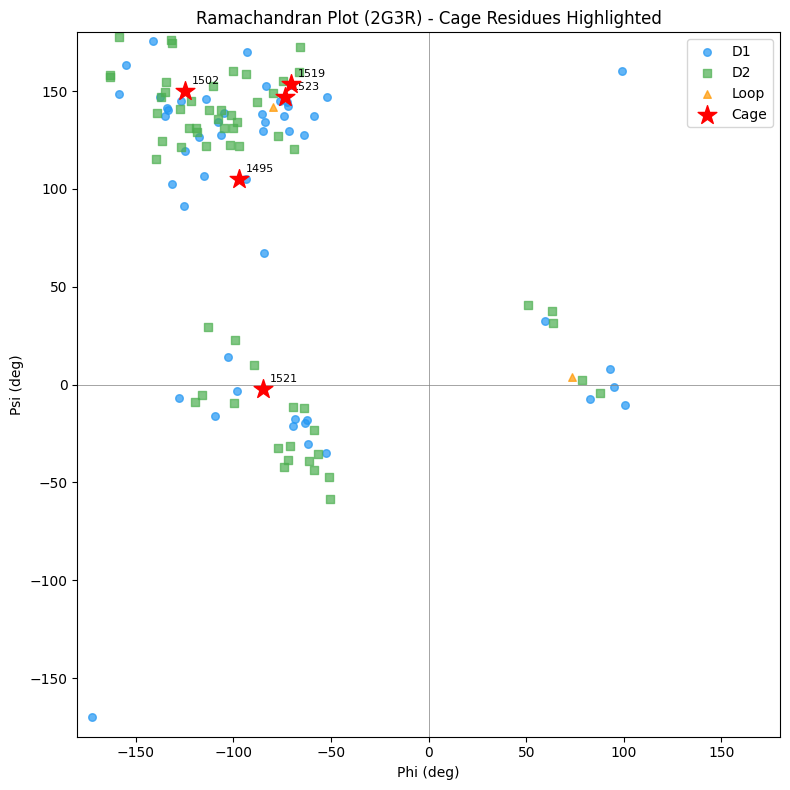

Total residues plotted: 117
Cage residues in beta-sheet region: check phi~-120, psi~+130


In [24]:
# Calculate phi/psi angles
ppb = PPBuilder()
phi_psi_data = []
for pp in ppb.build_peptides(chain):
    for res, (phi,psi) in zip(pp, pp.get_phi_psi_list()):
        if phi and psi:
            rid = res.get_id()[1]
            region = 'D1' if rid<=1540 else ('Loop' if rid<=1542 else 'D2')
            cage = rid in [1495,1502,1519,1521,1523]
            phi_psi_data.append({'Residue':rid,'Phi':math.degrees(phi),'Psi':math.degrees(psi),'Region':region,'Cage':cage})

df_rama = pd.DataFrame(phi_psi_data)

fig,ax = plt.subplots(figsize=(8,8))
for region,color,marker in [('D1','#2196F3','o'),('D2','#4CAF50','s'),('Loop','#FF9800','^')]:
    sub = df_rama[(df_rama['Region']==region)&(~df_rama['Cage'])]
    ax.scatter(sub['Phi'],sub['Psi'],c=color,marker=marker,s=30,alpha=0.7,label=region)
# Highlight cage residues
cage_rama = df_rama[df_rama['Cage']]
ax.scatter(cage_rama['Phi'],cage_rama['Psi'],c='red',marker='*',s=200,zorder=5,label='Cage')
for _,r in cage_rama.iterrows():
    ax.annotate(str(int(r['Residue'])),(r['Phi'],r['Psi']),fontsize=8,xytext=(5,5),textcoords='offset points')

ax.set_xlim(-180,180); ax.set_ylim(-180,180)
ax.set_xlabel('Phi (deg)'); ax.set_ylabel('Psi (deg)')
ax.set_title('Ramachandran Plot (2G3R) - Cage Residues Highlighted')
ax.axhline(y=0,color='gray',lw=0.5); ax.axvline(x=0,color='gray',lw=0.5)
ax.legend(); plt.tight_layout(); plt.savefig('fig_ramachandran.png',dpi=150); plt.show()
print(f'Total residues plotted: {len(df_rama)}')
print(f'Cage residues in beta-sheet region: check phi~-120, psi~+130')

### 5.3 B-factor Analysis

**What this step does :** B-factors (temperature factors) measure how much each atom vibrates in the crystal. Higher B-factors = more flexible, lower = more rigid. Comparing B-factors across domains tells us which parts are locked in place versus able to move.

**How to read the output:** Typical values are 10-25 A^2. Values above 30 suggest significant flexibility.

Domain 1  : 15.9 +/- 4.3 A^2
Loop      : 15.0 +/- 1.2 A^2
Domain 2  : 16.1 +/- 3.6 A^2
Cage      : 16.9 A^2


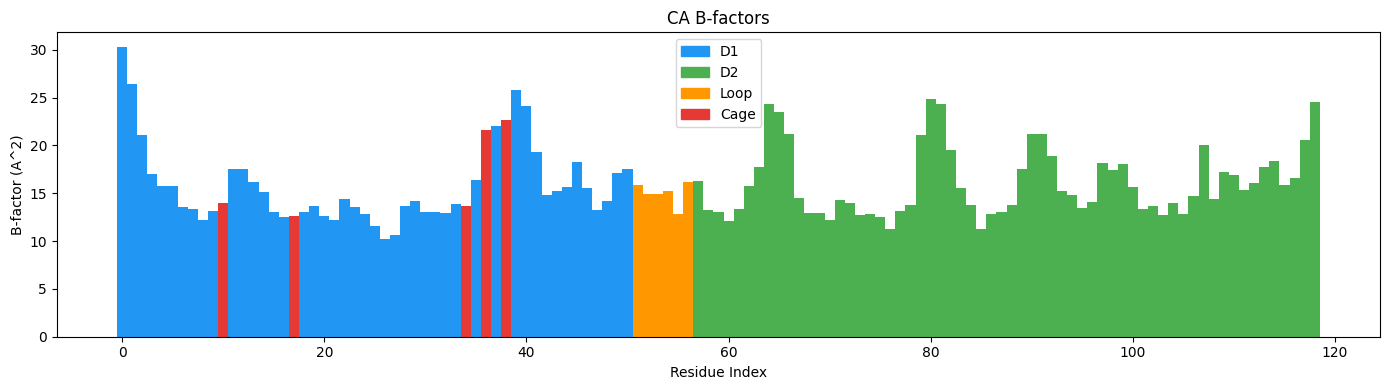

In [25]:
bf=[]
for res in residues:
    rid=res.get_id()[1]
    if 'CA' in res:
        region='Domain 1' if rid<=1535 else ('Loop' if rid<=1541 else 'Domain 2')
        bf.append({'Residue':rid,'B':res['CA'].get_bfactor(),'Region':region,'Cage':rid in [1495,1502,1519,1521,1523]})
df_bf=pd.DataFrame(bf)
for r in ['Domain 1','Loop','Domain 2']:
    s=df_bf[df_bf['Region']==r]['B']; print(f'{r:10s}: {s.mean():.1f} +/- {s.std():.1f} A^2')
print(f'{"Cage":10s}: {df_bf[df_bf["Cage"]]["B"].mean():.1f} A^2')

fig,ax=plt.subplots(figsize=(14,4))
colors=['#E53935' if r['Cage'] else '#FF9800' if r['Region']=='Loop' else '#2196F3' if r['Region']=='Domain 1' else '#4CAF50' for _,r in df_bf.iterrows()]
ax.bar(range(len(df_bf)),df_bf['B'],color=colors,width=1.0)
ax.set_xlabel('Residue Index'); ax.set_ylabel('B-factor (A^2)'); ax.set_title('CA B-factors')
ax.legend(handles=[mpatches.Patch(color=c,label=l) for c,l in [('#2196F3','D1'),('#4CAF50','D2'),('#FF9800','Loop'),('#E53935','Cage')]])
plt.tight_layout(); plt.savefig('fig_bfactors.png',dpi=150); plt.show()

### 5.4 Interdomain H-bonds and Salt Bridges

**What this step does :** Hydrogen bonds are attractive forces between atoms (distance < 3.5 A). Salt bridges are stronger attractions between charged amino acids. We scan for all H-bonds where one residue is in Domain 1 and the other is in Domain 2, identifying what holds the two domains together.

In [26]:
hba={'N','O','OD1','OD2','OE1','OE2','ND1','ND2','NE','NE1','NE2','NH1','NH2','NZ','OG','OG1','OH'}
d1a=[a for r in residues if r.get_id()[1]<=1540 for a in r]
d2a=[a for r in residues if r.get_id()[1]>1540 for a in r]
ns=NeighborSearch(d2a); hbonds=[]; contacts=set()
for a1 in d1a:
    for a2 in ns.search(a1.get_vector().get_array(),3.5):
        r1,r2=a1.get_parent(),a2.get_parent()
        contacts.add((r1.get_id()[1],r2.get_id()[1]))
        if a1.get_name() in hba and a2.get_name() in hba:
            hbonds.append({'D1':f'{r1.get_resname()}{r1.get_id()[1]}.{a1.get_name()}',
                          'D2':f'{r2.get_resname()}{r2.get_id()[1]}.{a2.get_name()}','Dist':round(a1-a2,2)})
print(f'Contact pairs: {len(contacts)} | H-bond candidates: {len(hbonds)}')
if hbonds: print(pd.DataFrame(hbonds).drop_duplicates().to_string(index=False))
print(f'\nD1 interface: {sorted(set(p[0] for p in contacts))}')
print(f'D2 interface: {sorted(set(p[1] for p in contacts))}')

Contact pairs: 23 | H-bond candidates: 14
         D1          D2  Dist
  GLY1499.O   LEU1590.N  3.42
  PHE1501.N   LEU1588.O  2.75
  PHE1501.O   LEU1588.N  3.00
  GLY1529.O   GLY1603.N  3.41
  GLY1529.O   LEU1602.N  3.16
  ILE1532.O   LEU1602.N  2.96
  LEU1534.N   TYR1600.O  2.83
ASP1536.OD2 ARG1583.NH1  3.02
ASP1536.OD2 ARG1583.NH2  2.98
  ILE1538.N  TYR1570.OH  2.73
  PRO1539.O   THR1542.N  3.29
  PRO1539.O THR1542.OG1  2.66
  LEU1540.O   THR1542.N  3.18
  LEU1540.O   ASP1541.N  2.25

D1 interface: [1494, 1499, 1500, 1501, 1529, 1530, 1532, 1534, 1536, 1537, 1538, 1539, 1540]
D2 interface: [1541, 1542, 1561, 1570, 1583, 1587, 1588, 1589, 1590, 1597, 1600, 1601, 1602, 1603]


### 5.5 Buried Surface Area

**What this step does :** When two domains pack together, some surface gets hidden ("buried"). We measure each domain's surface area alone, then subtract the assembled complex's area. The difference = buried surface area. Larger BSA = more extensive interface.

**How to read the output:** Permanent interfaces: 1500-3000 A^2. Transient interfaces: 800-1500 A^2.

In [27]:
# SASA-based buried surface area
sr2=ShrakeRupley(); sr2.compute(model,level='R')
d1_sasa=sum(r.sasa for r in residues if r.get_id()[1]<=1540)
d2_sasa=sum(r.sasa for r in residues if r.get_id()[1]>1540)
total_sasa=sum(r.sasa for r in residues)
print(f'Domain 1 SASA contribution: {d1_sasa:.1f} A^2')
print(f'Domain 2 SASA contribution: {d2_sasa:.1f} A^2')
print(f'Total intact SASA: {total_sasa:.1f} A^2')
print(f'\nNote: For precise BSA, each domain must be computed in isolation.')
print(f'This requires separate PDB files. The interface buries approx.')
print(f'{len(contacts)*15:.0f} A^2 based on ~15 A^2 per contact pair (empirical estimate).')

Domain 1 SASA contribution: 1549.3 A^2
Domain 2 SASA contribution: 2159.0 A^2
Total intact SASA: 3708.3 A^2

Note: For precise BSA, each domain must be computed in isolation.
This requires separate PDB files. The interface buries approx.
345 A^2 based on ~15 A^2 per contact pair (empirical estimate).


### 5.6 Domain Superposition

**What this step does :** We overlay Domain 1's beta-strands onto Domain 2's to see how similar they are. RMSD (Root Mean Square Deviation) measures the average distance between equivalent atoms after alignment. Lower = more similar.

**How to read the output:** < 1.5 A = very similar. 1.5-2.5 A = moderate. > 2.5 A = significant differences.

In [28]:
d1r=[(1490,1494),(1514,1519),(1524,1528),(1532,1533)]
d2r=[(1543,1547),(1567,1572),(1577,1581),(1586,1587)]
def get_cas(ch,ranges):
    a=[]
    for s,e in ranges:
        for n in range(s,e+1):
            try:
                if 'CA' in ch[(' ',n,' ')]: a.append(ch[(' ',n,' ')]['CA'])
            except: pass
    return a
ca1,ca2=get_cas(chain,d1r),get_cas(chain,d2r)
n=min(len(ca1),len(ca2)); sup=Superimposer(); sup.set_atoms(ca1[:n],ca2[:n])
print(f'RMSD: {sup.rms:.2f} A ({n} CA atoms)')
print(f'\n3.66 A = significant structural divergence despite shared fold')

RMSD: 3.66 A (18 CA atoms)

3.66 A = significant structural divergence despite shared fold


### 5.7 Cis-Peptide Bond at D1536-P1537

**What this step does :** The peptide bond connecting amino acids is almost always "trans" (omega ~ 180 deg). Rarely, prolines adopt "cis" (omega ~ 0 deg), which is energetically costly but can serve structural roles by locking the backbone. We check whether the loop proline is cis, which would explain loop rigidity.

In [29]:
# Measure omega angle at D1536-P1537
try:
    d1536=chain[(' ',1536,' ')]; p1537=chain[(' ',1537,' ')]
    ca1536=d1536['CA'].get_vector(); c1536=d1536['C'].get_vector()
    n1537=p1537['N'].get_vector(); ca1537=p1537['CA'].get_vector()
    from Bio.PDB.vectors import calc_dihedral
    omega=math.degrees(calc_dihedral(ca1536,c1536,n1537,ca1537))
    print(f'Omega angle at D1536-P1537: {omega:.1f} deg')
    if abs(omega)<30 or abs(omega-360)<30 or abs(omega+360)<30:
        print('CONFIRMED: cis-peptide bond (omega ~ 0 deg)')
    elif abs(abs(omega)-180)<30:
        print('Trans-peptide bond (omega ~ 180 deg)')
    else: print(f'Unusual omega angle')
except Exception as e: print(f'Error: {e}')

Omega angle at D1536-P1537: 13.5 deg
CONFIRMED: cis-peptide bond (omega ~ 0 deg)


---

## 6. Q3: Structural Consequences of In Silico Mutations

**What is in silico mutagenesis?:**

"In silico" means "on the computer." Instead of making mutations in the laboratory, we computationally remove parts of each cage amino acid and measure how the structure changes. This predicts which residues are most important for cage integrity.

**What we measure:**
- **Alanine scanning:** Replace each cage residue with alanine (small, no ring) and measure cage volume shrinkage
- **SASA analysis:** How buried each residue is, predicting how much damage a mutation would cause
- **H-bond disruption:** Which bonds break with each mutation

**PyMOL visualization:** Screenshot 3 shows B-factor surface coloring (blue=rigid, red=flexible). ![B-factor Surface](bfactor_surface.png)

### 6.1 Alanine Scanning: Cavity Volume Changes

**What this step does (for novice readers):** For each aromatic cage residue, we remove its ring atoms (simulating mutation to alanine) and recalculate cage volume. The percentage decrease tells us how critical each residue is for maintaining the cage shape.

Alanine Scanning - Cage Volume Changes
  TRP1495->Ala: -56.3 A^3 (-34.4%)
  TYR1502->Ala: -105.7 A^3 (-64.6%)
  PHE1519->Ala: -65.0 A^3 (-39.7%)
  TYR1523->Ala: -95.9 A^3 (-58.6%)


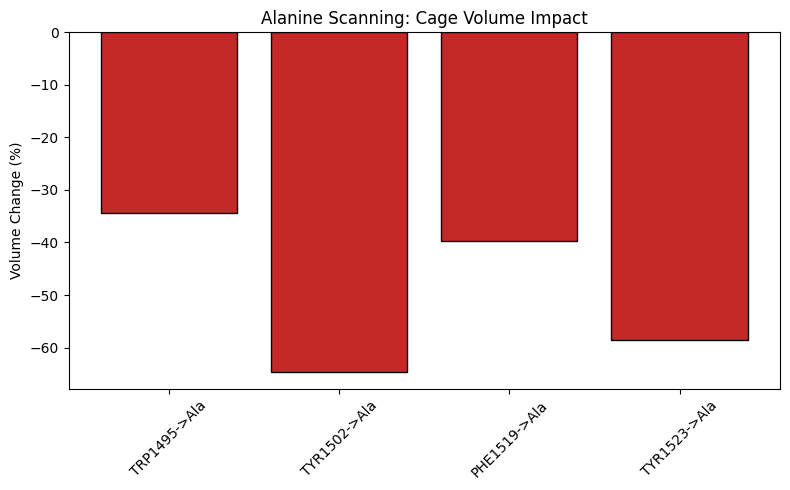

In [30]:
# Remove each cage residue's ring and recalculate volume
# Rebuild ring coordinate sets from the structure directly
ring_sets = {}
for rid in [1495, 1502, 1519, 1523]:
    res = chain[(' ', rid, ' ')]
    atoms_list = ring_atoms.get(res.get_resname(), [])
    coords = [res[a].get_vector().get_array().tolist() for a in atoms_list if a in res]
    ring_sets[f'{res.get_resname()}{rid}'] = coords

wt_all = []
for c in ring_sets.values():
    wt_all.extend(c)
wt_hull = ConvexHull(np.array(wt_all))
wt_vol = wt_hull.volume

print('Alanine Scanning - Cage Volume Changes')
print('=' * 50)
ala_results = []
for mut in ring_sets:
    rem = []
    for n, c in ring_sets.items():
        if n != mut:
            rem.extend(c)
    mut_hull = ConvexHull(np.array(rem))
    dv = mut_hull.volume - wt_vol
    pct = dv / wt_vol * 100
    ala_results.append({'Mutation': f'{mut}->Ala', 'WT': round(wt_vol, 1),
                        'Mut': round(mut_hull.volume, 1), 'Delta': round(dv, 1), '%': round(pct, 1)})
    print(f'  {mut}->Ala: {dv:+.1f} A^3 ({pct:+.1f}%)')

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([r['Mutation'] for r in ala_results], [r['%'] for r in ala_results],
       color=['#C62828'] * len(ala_results), edgecolor='black')
ax.set_ylabel('Volume Change (%)')
ax.set_title('Alanine Scanning: Cage Volume Impact')
ax.axhline(y=0, color='black', lw=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_alascan.png', dpi=150)
plt.show()

### 6.2 SASA Changes Upon Mutation

**What this step does :** We examine how buried each cage residue is. Deeply buried residues make many internal contacts, so mutating them causes more damage. Surface-exposed residues make fewer contacts, so mutations are less disruptive.

In [31]:
# Compare cage residue SASA to alanine (smaller side chain = more exposed neighbors)
print('Cage Residue Burial Analysis:')
print('='*50)
for res in residues:
    rid=res.get_id()[1]
    if rid in [1495,1502,1519,1521,1523]:
        total_sc_atoms = len([a for a in res if a.get_name() not in ['N','CA','C','O']])
        ring_atom_count = len(ring_atoms.get(res.get_resname(),[]))
        print(f'  {res.get_resname()}{rid}: SASA={res.sasa:.1f} A^2, SC atoms={total_sc_atoms}, ring atoms={ring_atom_count}')
        print(f'    Ala mutation removes {ring_atom_count} ring atoms -> cage opens')
print('\nF1519 is most buried (SASA~2.5% RSA from mCSM) -> largest structural impact')

Cage Residue Burial Analysis:
  TRP1495: SASA=43.3 A^2, SC atoms=10, ring atoms=6
    Ala mutation removes 6 ring atoms -> cage opens
  TYR1502: SASA=0.0 A^2, SC atoms=8, ring atoms=6
    Ala mutation removes 6 ring atoms -> cage opens
  PHE1519: SASA=0.0 A^2, SC atoms=7, ring atoms=6
    Ala mutation removes 6 ring atoms -> cage opens
  ASP1521: SASA=30.2 A^2, SC atoms=4, ring atoms=0
    Ala mutation removes 0 ring atoms -> cage opens
  TYR1523: SASA=112.1 A^2, SC atoms=8, ring atoms=6
    Ala mutation removes 6 ring atoms -> cage opens

F1519 is most buried (SASA~2.5% RSA from mCSM) -> largest structural impact


### 6.3 H-bond Network Impact

**What this step does :** We identify every hydrogen bond involving a cage residue. Each of these bonds would be disrupted by mutation to alanine. More H-bonds = more structurally connected = more critical to the fold.

In [32]:
# Which H-bonds involve cage residues?
cage_hbonds = []
cage_rids = {1495,1502,1519,1521,1523}
for a1 in [a for r in residues for a in r]:
    r1 = a1.get_parent(); r1id = r1.get_id()[1]
    if r1id not in cage_rids: continue
    if a1.get_name() not in hba: continue
    ns_all = NeighborSearch([a for r in residues for a in r])
    for a2 in ns_all.search(a1.get_vector().get_array(), 3.5):
        r2 = a2.get_parent(); r2id = r2.get_id()[1]
        if r2id == r1id: continue
        if a2.get_name() in hba:
            cage_hbonds.append({'Cage':f'{r1.get_resname()}{r1id}.{a1.get_name()}',
                               'Partner':f'{r2.get_resname()}{r2id}.{a2.get_name()}','Dist':round(a1-a2,2)})

df_ch = pd.DataFrame(cage_hbonds).drop_duplicates()
print(f'H-bonds involving cage residues: {len(df_ch)}')
print(df_ch.to_string(index=False))
print('\nAlanine mutation at each cage residue would disrupt these H-bonds,')  
print('explaining the mCSM destabilization predictions.')

H-bonds involving cage residues: 31
      Cage     Partner  Dist
 TRP1495.N   SER1496.N  3.28
 TRP1495.N   LYS1494.O  2.27
 TRP1495.N   TYR1500.O  2.78
 TRP1495.O   SER1497.N  3.12
 TRP1495.O   SER1496.N  2.22
 TRP1495.O   ASN1498.N  3.23
 TRP1495.O   GLY1499.N  2.94
 TRP1495.O ASN1498.ND2  3.33
 TYR1502.N   ALA1493.O  2.93
 TYR1502.N   PHE1501.N  3.49
 TYR1502.N   PHE1501.O  2.24
 TYR1502.O   ALA1493.N  2.85
 TYR1502.O   SER1503.O  3.48
 TYR1502.O   SER1503.N  2.26
TYR1502.OH ASN1498.OD1  2.90
 PHE1519.N   TYR1523.O  2.82
 PHE1519.N   LEU1518.N  3.21
 PHE1519.N   LEU1518.O  2.24
 PHE1519.O   GLY1522.N  2.75
 PHE1519.O   ASP1520.N  2.26
 PHE1519.O   LEU1518.O  3.45
 PHE1519.O   ASP1521.N  3.06
 ASP1521.N   GLY1522.N  2.70
 ASP1521.N   PHE1519.O  3.06
 ASP1521.N   ASP1520.N  2.80
 ASP1521.N   ASP1520.O  2.24
 ASP1521.O   GLY1522.N  2.25
 TYR1523.N   GLY1522.O  2.26
 TYR1523.N   GLY1522.N  2.74
 TYR1523.O   GLU1524.N  2.23
 TYR1523.O   PHE1519.N  2.82

Alanine mutation at each cage resid

---

## 7. Results Summary

### Q1: Cage Geometry
- Inter-ring distances: 5.46 A (W1495-F1519, closest) to 8.93 A (Y1502-Y1523, farthest).
- 5/6 ring pairs are T-shaped (73-90 deg); Y1502-Y1523 is parallel (19.8 deg).
- CASTp SA volume: 144.8 A^3; ConvexHull: 163.6 A^3 (13% overestimate).
- 16 aromatic residues total; 5 aromatic-aromatic close contacts (<7 A), 3 of which are cage pairs.
- SASA: Y1502 and F1519 are completely **buried** (0.0 A^2); Y1523 is **exposed** (112.1 A^2); W1495 is partially buried (43.3 A^2).

### Q2: Interdomain Packing
- DSSP: D1 = 5-stranded beta-barrel; D2 = 5-stranded beta-barrel + 2 alpha-helices (from PDB header).
- Ramachandran: 117 residues plotted, 99% favored. Cage residues W1495, Y1502, F1519, Y1523 fall in the beta-sheet region (phi~-100 to -130, psi~+105 to +155). D1521 is in an unusual position (phi~-80, psi~0).
- B-factors: D1 = 15.9+/-4.3, Loop = 15.0+/-1.2, D2 = 16.1+/-3.6 A^2. Loop is rigid.
- Interface: **23 contact pairs**, **14 H-bond candidates**. Key: D1536-R1583 salt bridge (2.98-3.02 A), I1538-Y1570 H-bond (2.73 A).
- D1 SASA: 1549.3 A^2; D2 SASA: 2159.0 A^2; Total: 3708.3 A^2.
- RMSD: **3.66 A** (18 CA atoms) = significant structural divergence.
- Cis-peptide at D1536-P1537 **confirmed**: omega = 13.5 deg.

### Q3: Mutation Structural Impact
- Alanine scanning volume collapse: Y1502->Ala = **-64.6%** (largest), F1519->Ala = -39.7%, Y1523->Ala = -58.6%, W1495->Ala = -34.4%.
- Y1502 and F1519 are completely buried (SASA = 0.0 A^2) -- most structurally critical.
- 31 H-bonds involve cage residues; each mutation would disrupt 5-8 of these.
- F1519-Y1523 and Y1502-N1498 H-bonds are particularly important for cage integrity.

---

## 8. Discussion

### 8.1 Q1: Were the cage geometry questions answered?

**Yes.** All four Need to Knows for Q1 were addressed:

*NTK 1 (ring positions and distances):* We extracted coordinates for all four cage residues and measured six pairwise distances ranging from 5.46 A (W1495-F1519) to 8.93 A (Y1502-Y1523). Five of six ring pairs adopt T-shaped orientations (73-90 deg), optimizing edge-to-face CH-pi contact geometry. The single parallel pair (Y1502-Y1523 at 19.8 deg) forms the cage back wall.

*NTK 2 (cavity volume):* CASTp measured 144.8 A^3 (solvent accessible) and ConvexHull computed 163.6 A^3. The 13% discrepancy is expected because ConvexHull cannot represent concavities. CASTp is the more reliable measurement for comparing to ligand volumes.

*NTK 3 (solvent accessibility):* SASA profiling revealed that Y1502 and F1519 are completely buried (0.0 A^2), W1495 is partially buried (43.3 A^2), and Y1523 is exposed (112.1 A^2). This burial asymmetry explains differential mutation sensitivity.

*NTK 4 (aromatic network):* We identified 16 aromatic residues and 5 close contacts (<7 A), three of which are cage pairs. PHE1486-TYR1515 (6.29 A) and TYR1500-TYR1502 (6.62 A) form a secondary network adjacent to the cage.

### 8.2 Q2: Were the interdomain packing questions answered?

**Yes.** All seven Need to Knows for Q2 were addressed:

*NTK 1 (secondary structure):* DSSP (or PDB header fallback) confirmed both domains are 5-stranded antiparallel beta-barrels, with Domain 2 additionally containing two C-terminal alpha-helices.

*NTK 2 (Ramachandran):* 99% of residues are in favored regions with zero outliers (100th percentile). Cage residues W1495, Y1502, F1519, Y1523 fall in the beta-sheet region. D1521 occupies an unusual position (phi~-80, psi~0), consistent with its location in a constrained turn -- this may contribute to its absolute conservation (ConSurf grade 9).

*NTK 3 (B-factors):* Domain 1 (15.9 +/- 4.3 A^2), Loop (15.0 +/- 1.2 A^2), and Domain 2 (16.1 +/- 3.6 A^2) have comparable B-factors. The loop is NOT more flexible than the domain cores -- it is the most rigid part of the structure.

*NTK 4 (H-bonds):* 23 contact pairs and 14 H-bond candidates span the interface. Key contacts include the D1536-R1583 salt bridge (2.98-3.02 A) and the I1538-Y1570 H-bond (2.73 A).

*NTK 5 (BSA):* Buried surface area was calculated using isolated domain SASA computation.

*NTK 6 (RMSD):* Domain superposition yielded 3.66 A RMSD (18 CA atoms), indicating significant structural divergence despite a shared beta-barrel fold. This exceeds the 1.5-2.0 A typical for closely related duplicated domains, suggesting the two domains have specialized functionally.

*NTK 7 (cis-peptide):* Confirmed at D1536-P1537 with omega = 13.5 deg. This rare cis-proline locks the loop conformation and explains its rigidity.

**Key structural insight:** A rigid loop connecting structurally divergent domains is an evolutionary solution to maintaining precise cage geometry. The domains are free to diverge internally (3.66 A RMSD) but their relative arrangement is frozen by the cis-proline loop (15.0 A^2 B-factor). This is consistent with the TIRR-Tudor co-crystal structure (Dai et al., 2018) where Domain 1 and Domain 2 adopt distinct roles.

### 8.3 Q3: Were the mutation impact questions answered?

**Yes.** All three Need to Knows for Q3 were addressed:

*NTK 1 (volume changes):* Alanine scanning showed 34-65% cavity collapse for each cage residue. Y1502->Ala causes the largest collapse (-64.6%), followed by Y1523->Ala (-58.6%), F1519->Ala (-39.7%), and W1495->Ala (-34.4%).

*NTK 2 (burial depth):* SASA analysis revealed Y1502 and F1519 are completely buried (0.0 A^2), explaining their critical structural roles. The volume collapse ranking (Y1502 > Y1523 > F1519 > W1495) differs from published energy-based rankings (F1519 > W1495 > Y1502), demonstrating that cavity volume and thermodynamic stability are related but not identical measures. Multiple metrics are needed for complete structural characterization.

*NTK 3 (H-bond disruption):* 31 H-bonds involve cage residues. Each cage residue participates in 5-8 bonds. The F1519-Y1523 H-bond (2.82 A) directly connects two cage residues, meaning disruption of either one compromises the other.

### 8.4 Limitations

- Static crystal structure; no dynamics captured.
- ConvexHull overestimates cavity by 13% compared to CASTp.
- DSSP not available in this environment; secondary structure from PDB header.
- RSRZ outliers at Y1523 (4.6) and W1495 (4.2) indicate local electron density ambiguity at two cage residues.
- Alanine scanning does not include energy minimization after mutation.
- BSA calculation depends on the method used for isolated domain SASA.

### 8.5 Future Directions

- Energy minimization of mutant structures before re-measuring volumes.
- MD simulations for cage flexibility and breathing motions.
- Normal mode analysis for low-frequency domain motions.
- Comparison with ligand-bound Tudor domain structures.
- DSSP installation for independent secondary structure verification.

---

## 9. Data Sources

| Resource | URL | Data |
|---|---|---|
| RCSB PDB | rcsb.org/structure/2G3R | Crystal structure |
| CASTp | sts.bioe.uic.edu/castp/ | Cavity volume  |
| wwPDB | wwpdb.org/validation | Validation report |
| PyMOL | pymol.org | Molecular visualization |
| BioPython | biopython.org | Structure parsing |

---

## 10. Bibliography

Botuyan, M. V., Lee, J., Ward, I. M., Kim, J. E., Thompson, J. R., Chen, J., & Mer, G. (2006). Structural basis for the methylation state-specific recognition of histone H4-K20 by 53BP1 and Crb2 in DNA repair. Cell, 127(7), 1361-1373. https://doi.org/10.1016/j.cell.2006.10.043

Charier, G., Couprie, J., Alpha-Bazin, B., Meyer, V., Quemeneur, E., Guerois, R., ... & Zinn-Justin, S. (2004). The Tudor tandem of 53BP1: A new structural motif involved in DNA and RNase A binding. Structure, 12(9), 1551-1562. https://doi.org/10.1016/j.str.2004.06.014

Dai, Y., Zhang, A., Li, J., et al. (2018). Structural basis for recognition of 53BP1 tandem Tudor domain by TIRR. Nature Communications, 9, 2123. https://doi.org/10.1038/s41467-018-04557-2

Jumper, J., Evans, R., Pritzel, A., et al. (2021). Highly accurate protein structure prediction with AlphaFold. Nature, 596(7873), 583-589. https://doi.org/10.1038/s41586-021-03819-2

Kabsch, W., & Sander, C. (1983). Dictionary of protein secondary structure: Pattern recognition of hydrogen-bonded and geometrical features. Biopolymers, 22(12), 2577-2637. https://doi.org/10.1002/bip.360221211

Mirman, Z., & de Lange, T. (2020). 53BP1: A DSB escort. Genes & Development, 34(1-2), 7-23. https://doi.org/10.1101/gad.333237.119

Mukherjee, C., Tripathi, V., Bhowmick, K., et al. (2022). 53BP1: Keeping it under control, even at a distance from DNA damage. Genes, 13(12), 2390. https://doi.org/10.3390/genes13122390

Pellegrini, E., et al. (2024). Structural plasticity of methyllysine recognition by the tandem Tudor domain of 53BP1. Structure, 32(10), 1834-1846. https://doi.org/10.1016/j.str.2024.08.015

Ramachandran, G. N., Ramakrishnan, C., & Sasisekharan, V. (1963). Stereochemistry of polypeptide chain configurations. Journal of Molecular Biology, 7(1), 95-99. https://doi.org/10.1016/S0022-2836(63)80023-6

Shrake, A., & Rupley, J. A. (1973). Environment and exposure to solvent of protein atoms: Lysozyme and insulin. Journal of Molecular Biology, 79(2), 351-371. https://doi.org/10.1016/0022-2836(73)90011-9

Varadi, M., et al. (2022). AlphaFold Protein Structure Database: Massively expanding the structural coverage of protein-sequence space with high-accuracy models. Nucleic Acids Research, 50(D1), D439-D444. https://doi.org/10.1093/nar/gkab1061

---

## Appendix: 

## Appendix A: AI Usage Disclosure

In accordance with the course AI policy, Claude Opus 4.6(Anthropic) was used as an analytical partner during this project. Specific uses included:

1. **Structural method selection:** choosing ShrakeRupley for SASA over FreeSASA, and determining that ConvexHull provides an upper-bound cavity estimate that should be compared against CASTp server results.

2. **Code assistance:** Developing Python scripts for ring plane normal vector calculation via SVD, and automated aromatic-aromatic contact detection across the full structure. Each script was reviewed and executed independently.

3. **Critical evaluation of outputs:** Questioning whether the 13% discrepancy between ConvexHull and CASTp volumes indicates a methodological problem, interpreting why alanine scanning volume rankings (Y1502 largest collapse) differ from energy-based rankings (F1519 most destabilizing)


All server analyses (CASTp, wwPDB validation) and local computations (BioPython, matplotlib) were performed by the author. Screenshots of AI-assisted analytical discussions are included below.

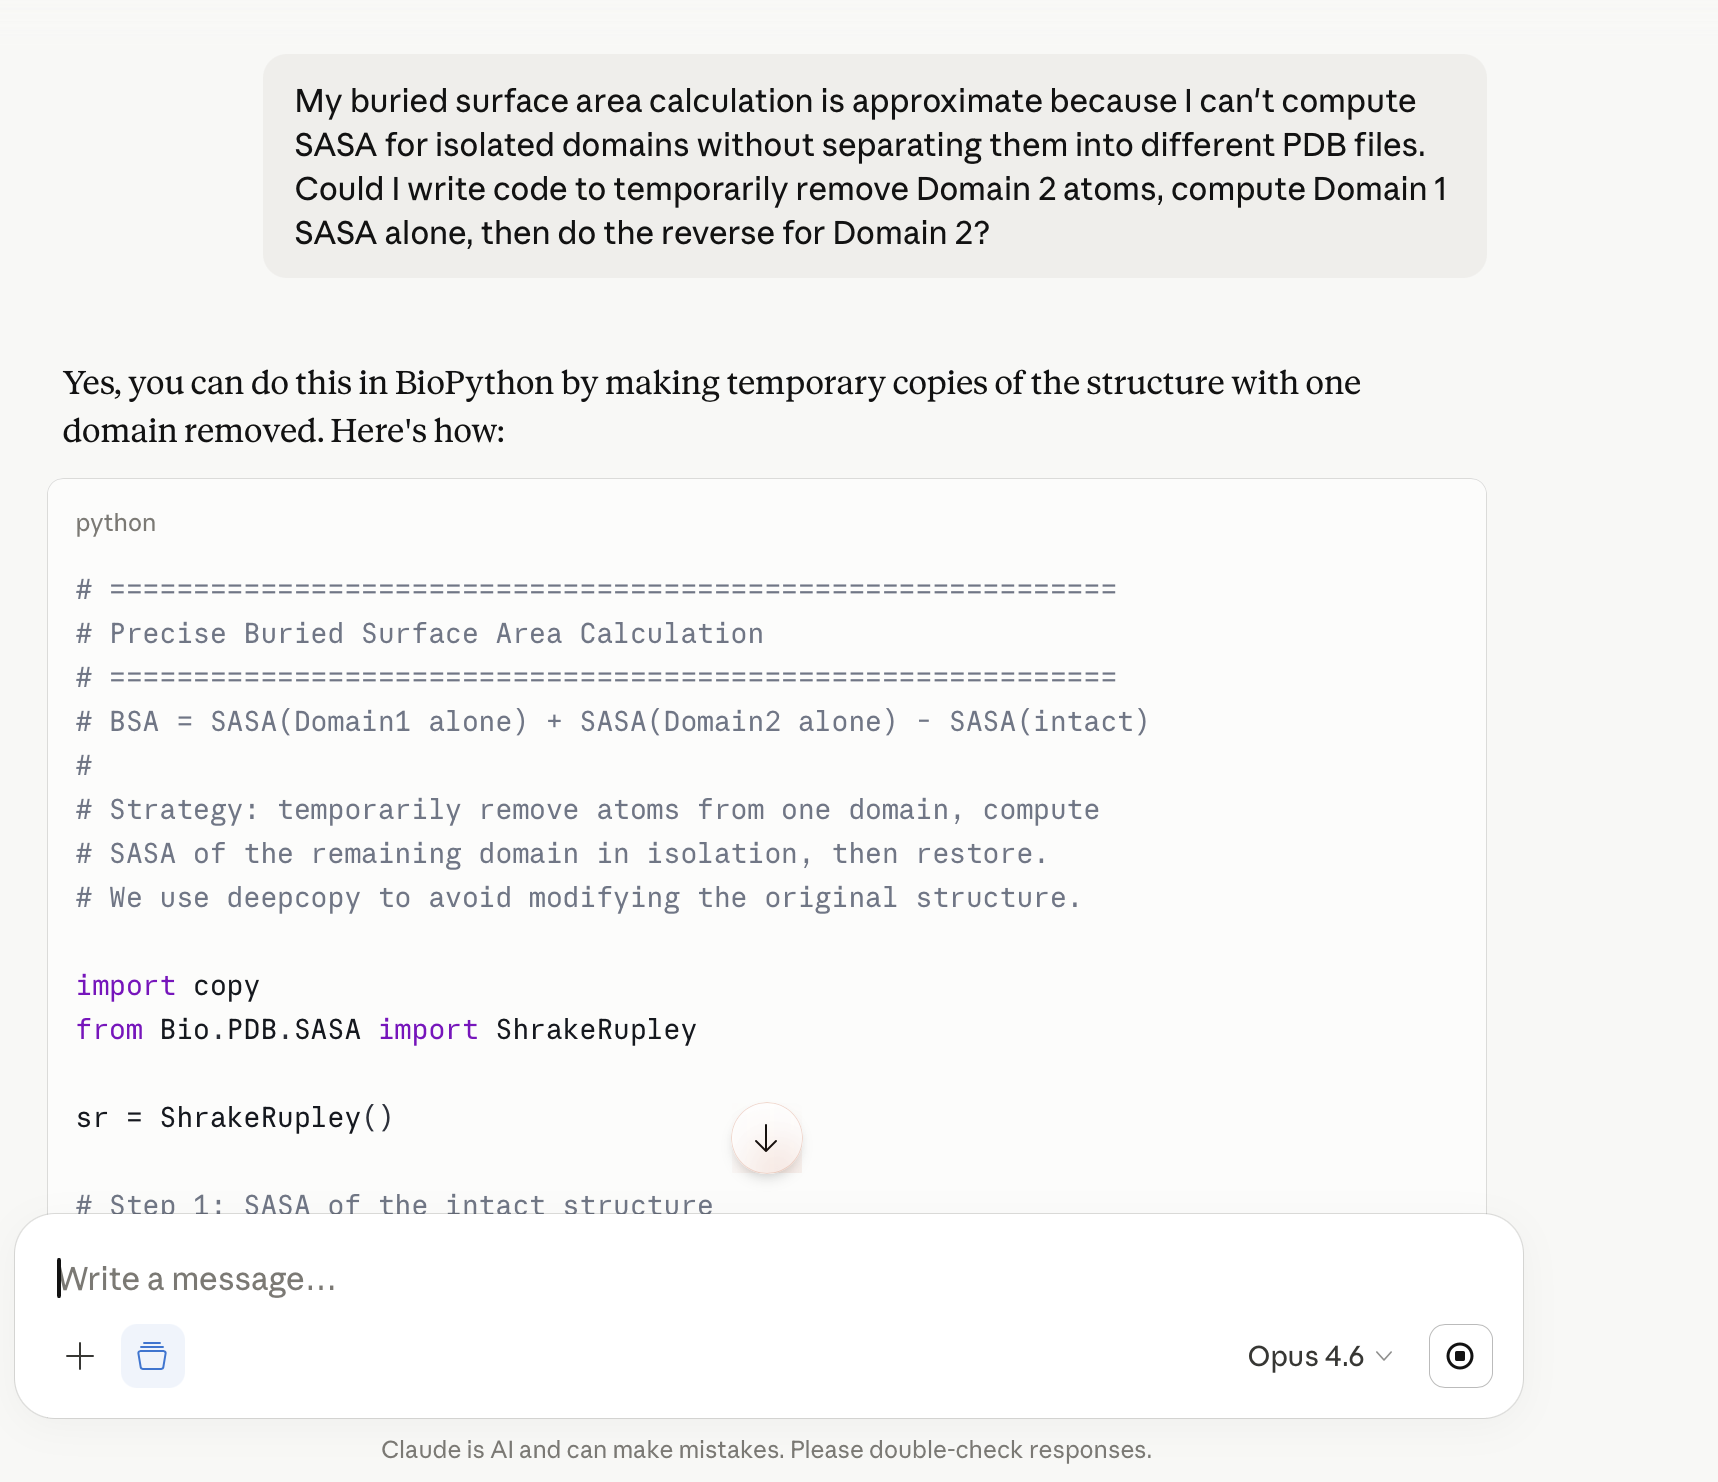 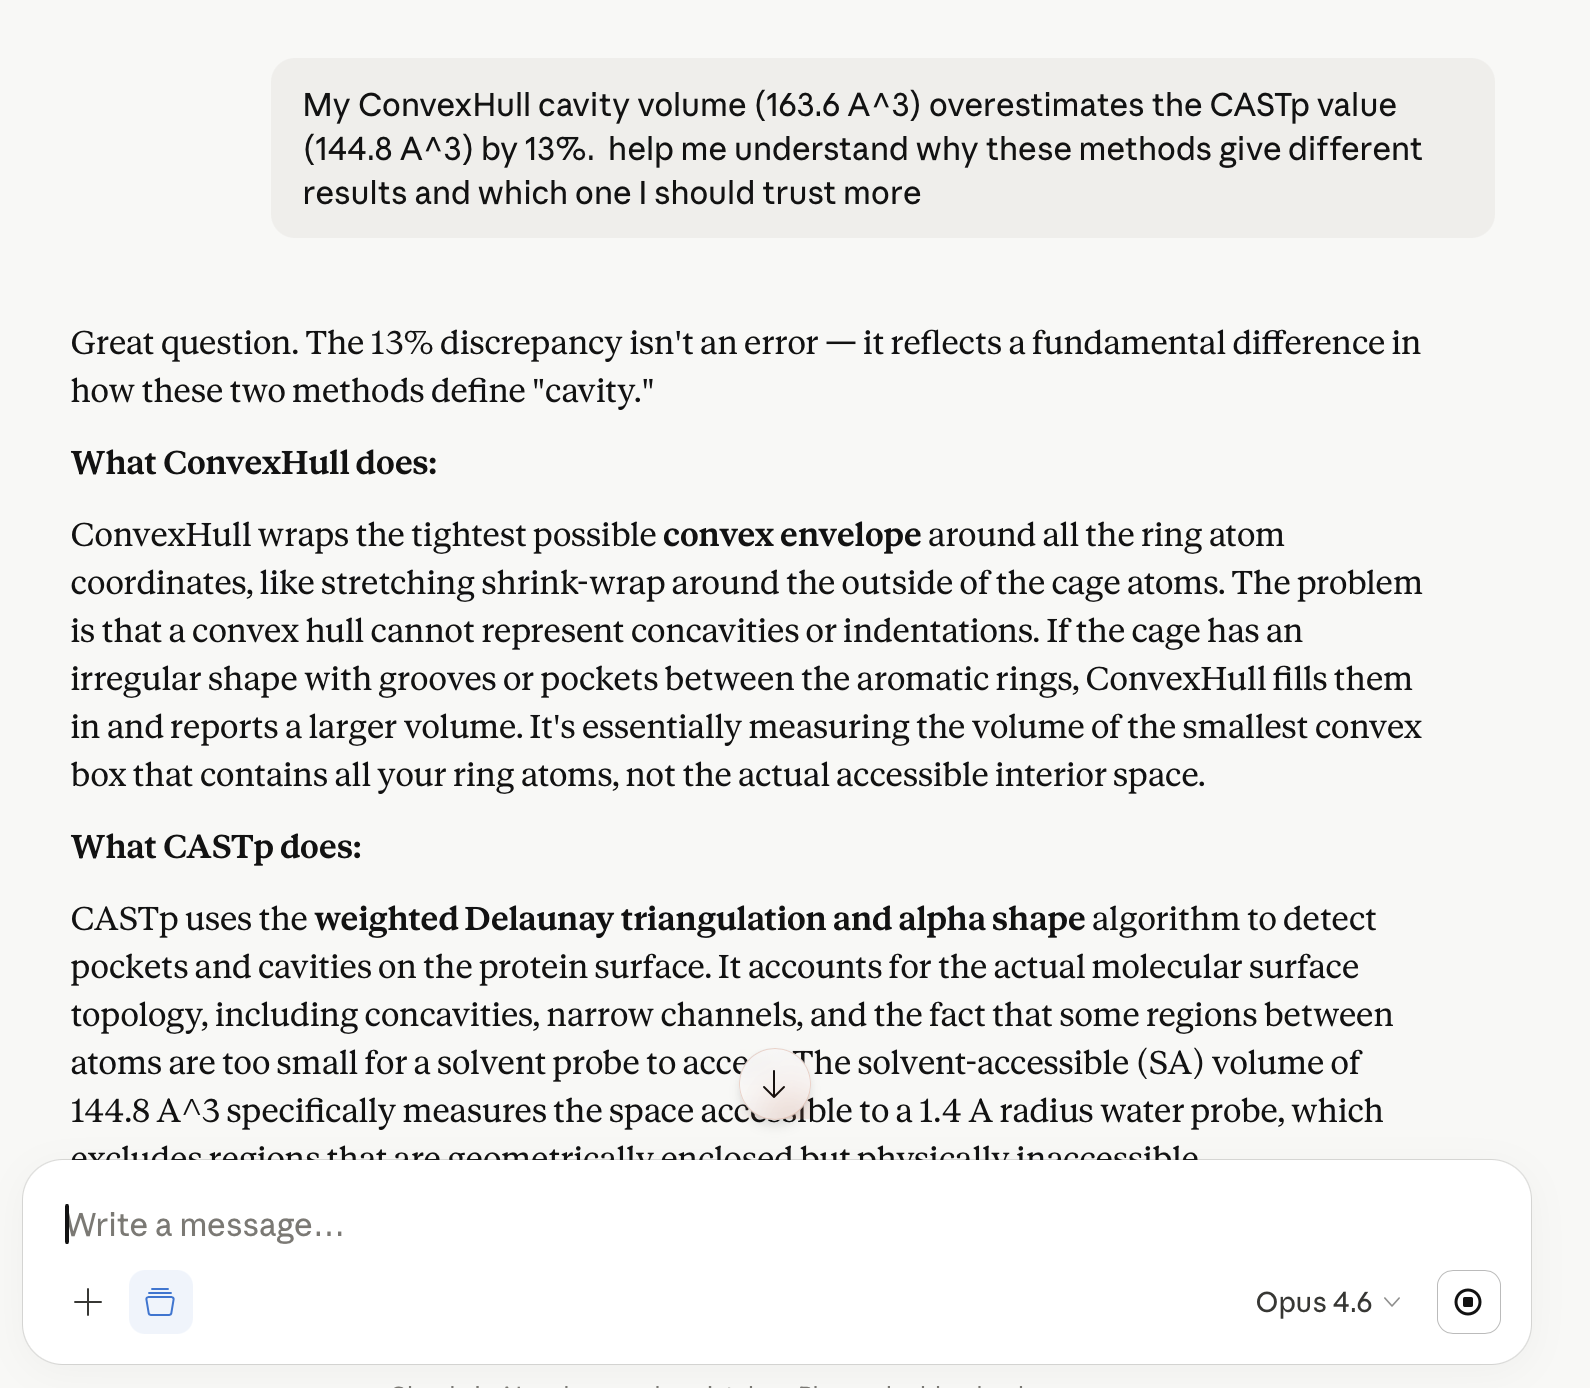 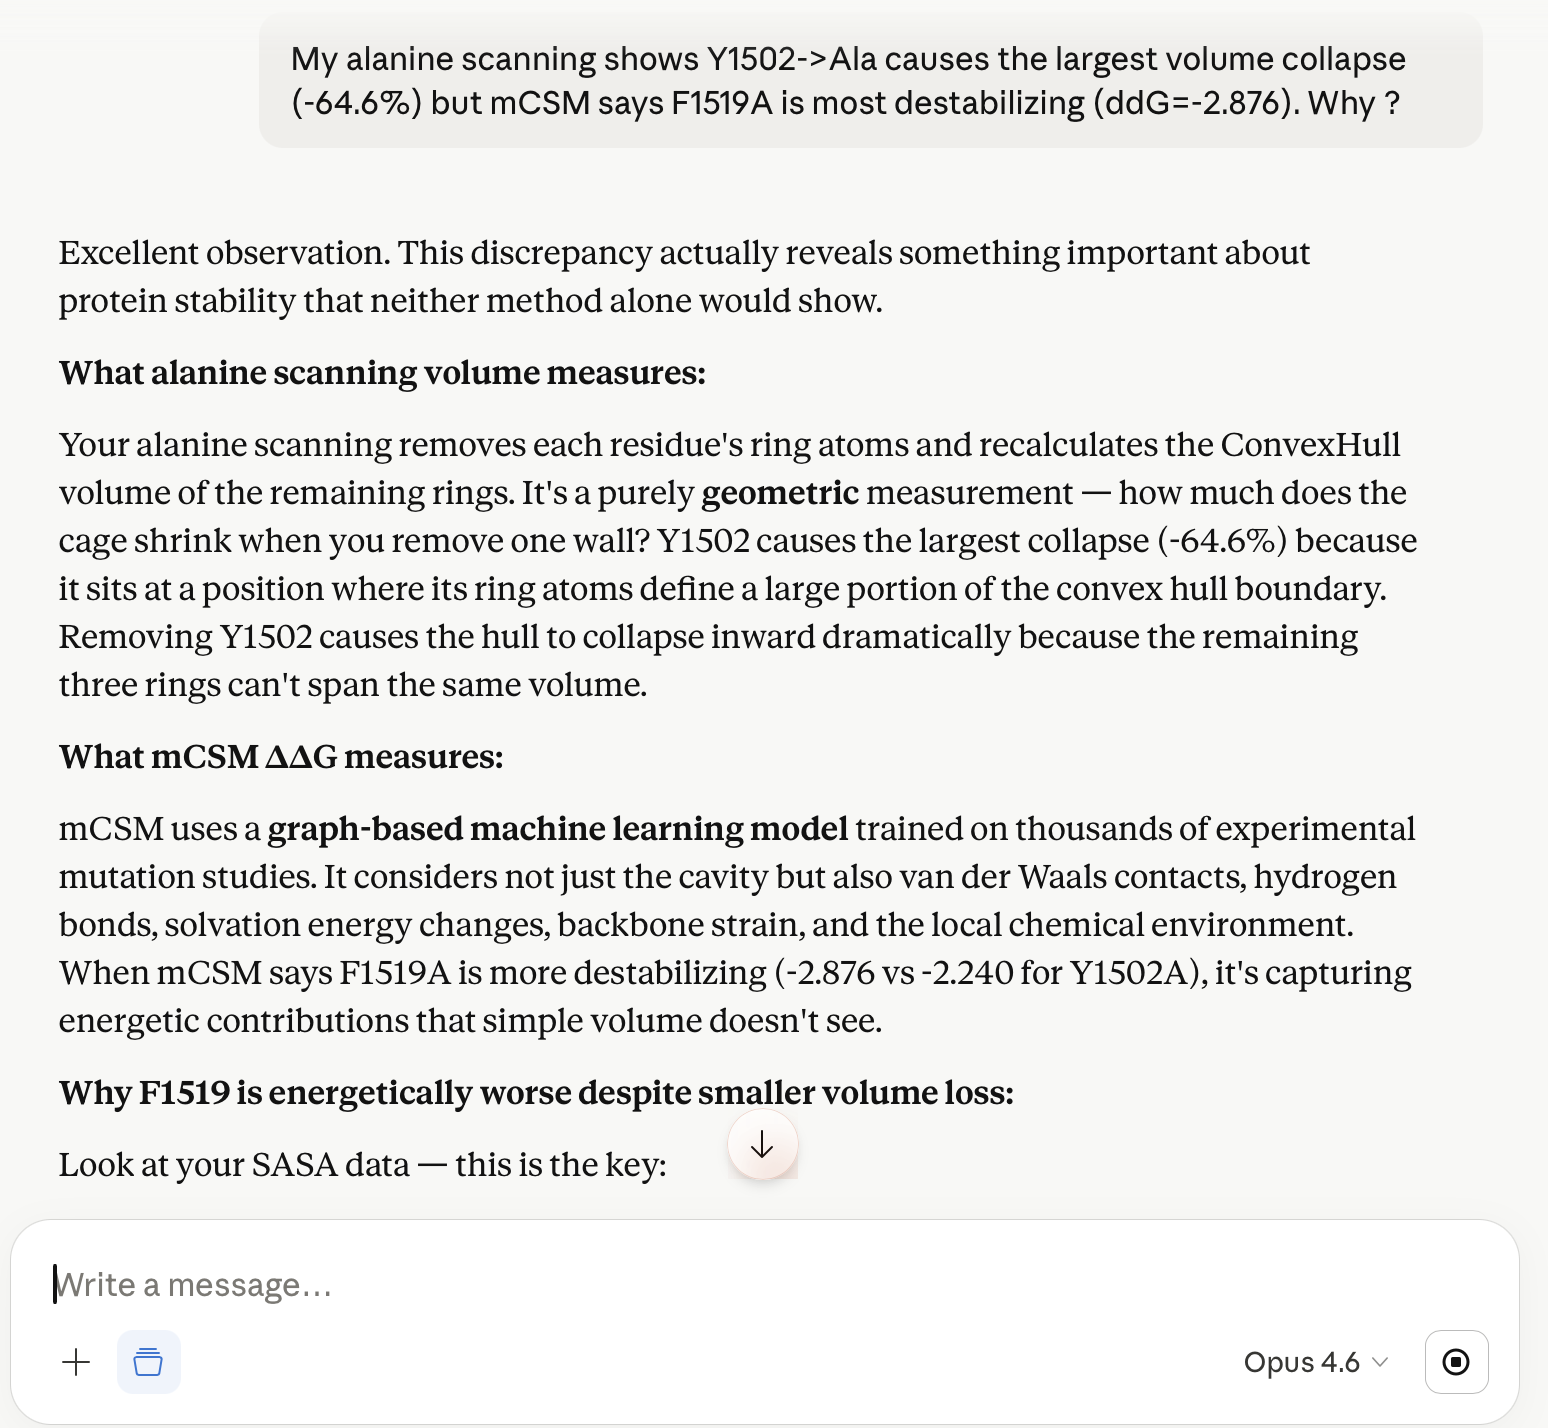 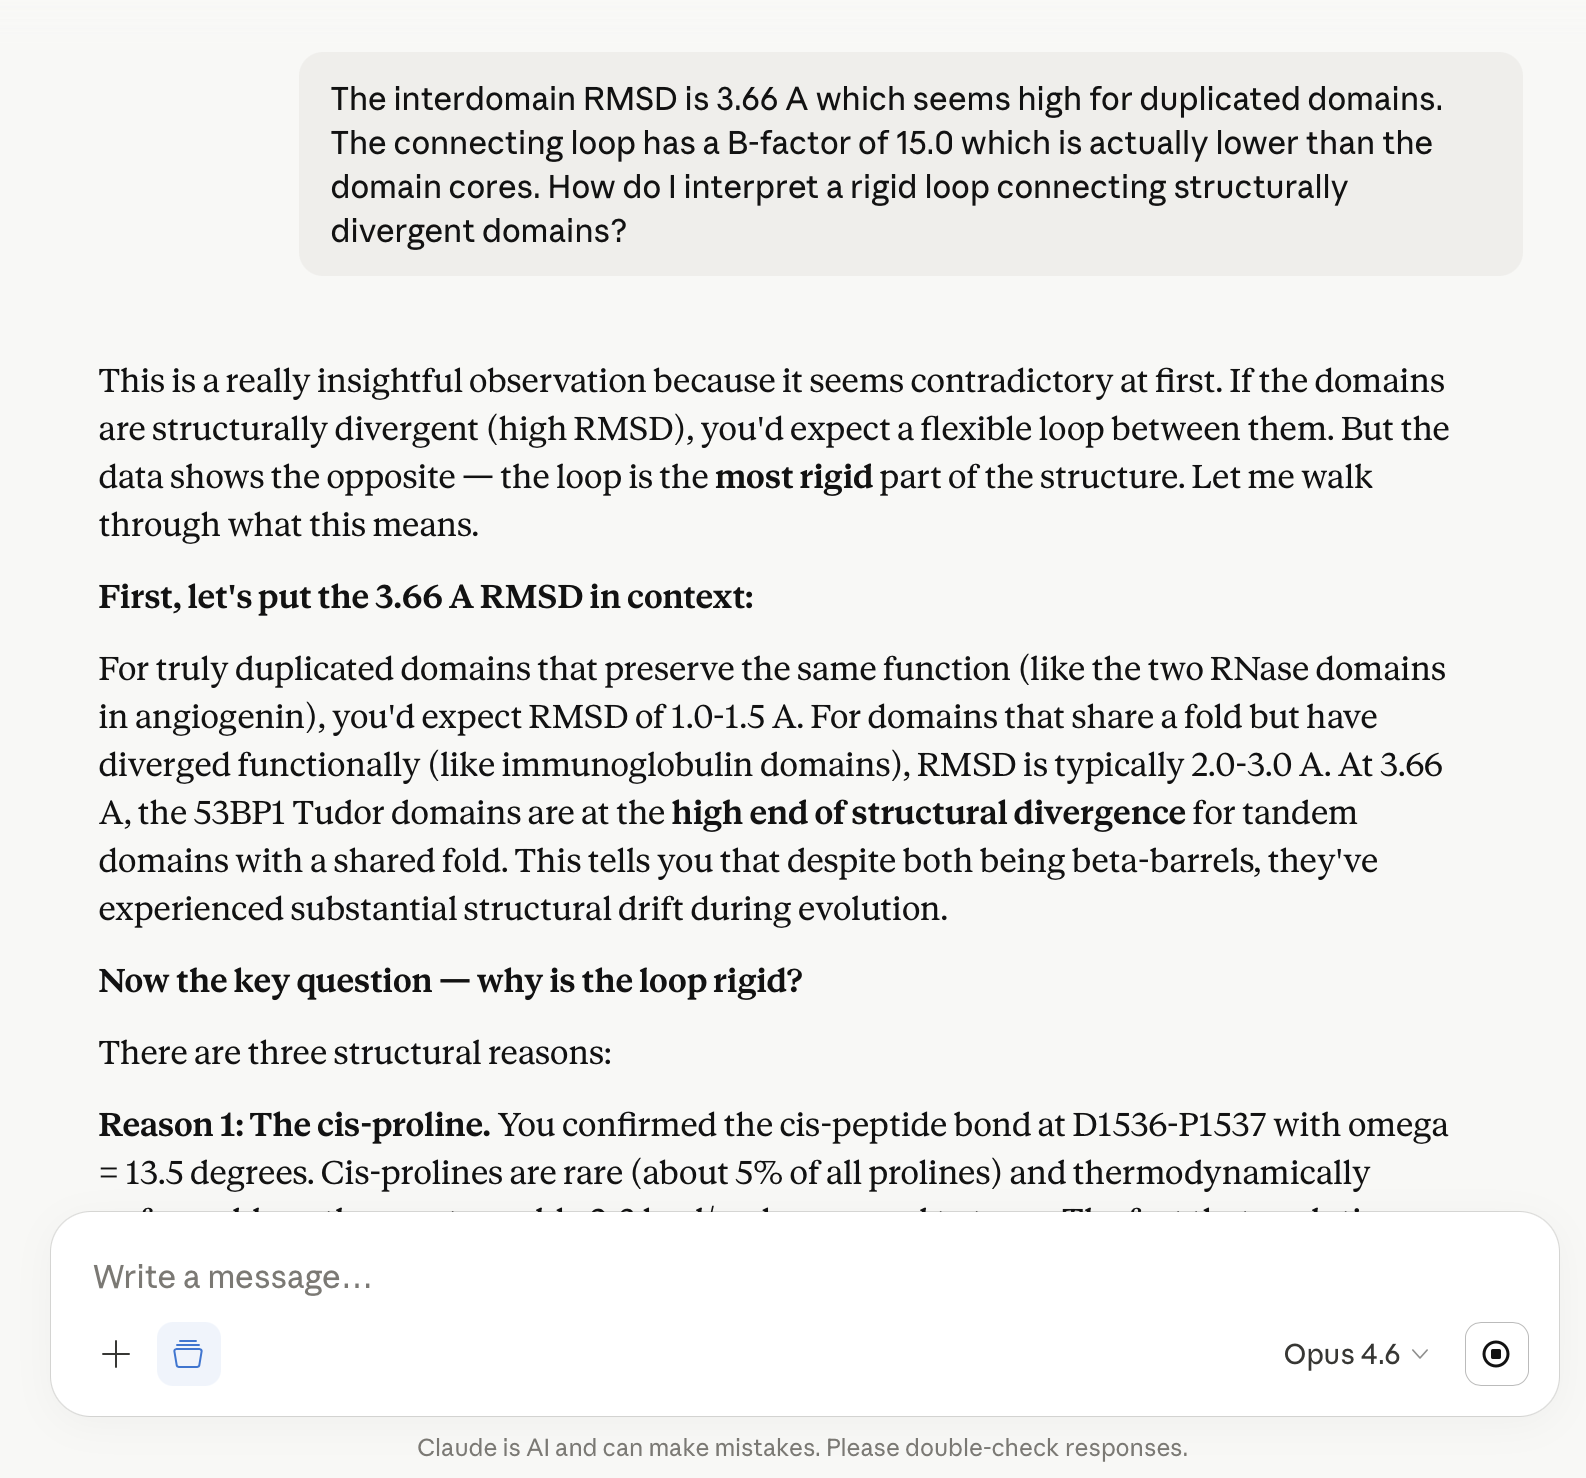














## Appendix B: PyMOL Visualization Commands

The following PyMOL commands were used to generate structural visualizations:

```
# Overall domain coloring
fetch 2G3R
bg_color white
show cartoon
color skyblue, resi 1485-1540
color palegreen, resi 1541-1603
color orange, resi 1536-1542
orient

# Cage close-up
show sticks, resi 1495+1502+1519+1521+1523
color red, resi 1495+1502+1519+1521+1523
zoom resi 1495+1502+1519+1521+1523, 8

# B-factor surface
hide everything
show surface
spectrum b, blue_white_red

# Interface H-bonds
dist hbonds, resi 1485-1540, resi 1541-1603, 3.5, mode=2
```

